# DSC540-T302 Data Preparation Term Project  
## Milestone 2 : Cleaning/Formatting Flat File Source

In [3]:
#Import pandas and read CSV file
import pandas as pd

csv_data = pd.read_csv("compact.csv")
csv_data.head() #Show first 5 rows of data

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578846.0,62.215546,16.752,NaN,1516.2733,NaN,10.9,48.214695,0.39,0.462
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578846.0,62.215546,16.752,NaN,1516.2733,NaN,10.9,48.214695,0.39,0.462
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578846.0,62.215546,16.752,NaN,1516.2733,NaN,10.9,48.214695,0.39,0.462
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578846.0,62.215546,16.752,NaN,1516.2733,NaN,10.9,48.214695,0.39,0.462
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578846.0,62.215546,16.752,NaN,1516.2733,NaN,10.9,48.214695,0.39,0.462


In [7]:
# STEP 1: Check current column names to make sure headers are named clearly:
print(csv_data.columns)
# Column names appear clear and descriptive as-is.

Index(['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed',
       'total_cases_per_million', 'new_cases_per_million',
       'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_deaths_per_million',
       'new_deaths_per_million', 'new_deaths_smoothed_per_million',
       'excess_mortality', 'excess_mortality_cumulative',
       'excess_mortality_cumulative_absolute',
       'excess_mortality_cumulative_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'icu_patients',
       'icu_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'stringency_index',
       'reproduction_rate', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'total_vaccinations',
    

In [5]:
# STEP 2: Keep only what I am deeming to be relevant columns

csv_data = csv_data[['country', 'code', 'date', 'new_cases',
       'new_deaths','excess_mortality','hosp_patients',
       'icu_patients', 'new_tests','positive_rate','total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations']]

# Check resulting columns
print(csv_data.columns)

Index(['country', 'code', 'date', 'new_cases', 'new_deaths',
       'excess_mortality', 'hosp_patients', 'icu_patients', 'new_tests',
       'positive_rate', 'total_vaccinations', 'people_vaccinated',
       'people_fully_vaccinated', 'total_boosters', 'new_vaccinations'],
      dtype='object')


In [7]:
#STEP 3: Convert Data Types

# First, adjust display settings so I can see all rows and columns
pd.set_option('display.max_rows', None)  # Make sure all rows are shown
pd.set_option('display.max_columns', None)  # Make sure all columns are shown


#Check the data type of entire DataFrame:
print(csv_data.dtypes)

country                     object
code                        object
date                        object
new_cases                  float64
new_deaths                 float64
excess_mortality           float64
hosp_patients              float64
icu_patients               float64
new_tests                  float64
positive_rate              float64
total_vaccinations         float64
people_vaccinated          float64
people_fully_vaccinated    float64
total_boosters             float64
new_vaccinations           float64
dtype: object


In [9]:
# I noticed that the date was an object data type so I will convert that to the appropriate datatype in pandas

#Convert 'date' column to datetime
csv_data['date'] = pd.to_datetime(csv_data['date'], errors='coerce')

#Check for any failed conversions NaT (Missing datetime values)
print(csv_data[csv_data['date'].isna()])

Empty DataFrame
Columns: [country, code, date, new_cases, new_deaths, excess_mortality, hosp_patients, icu_patients, new_tests, positive_rate, total_vaccinations, people_vaccinated, people_fully_vaccinated, total_boosters, new_vaccinations]
Index: []


In [11]:
# Now convert country and code columns from object type to string and remove any excess spaces
csv_data['country'] = csv_data['country'].astype(str).str.strip() #Use this syntax to convert specific columns and remove any spaces (country)
csv_data['code'] = csv_data['code'].astype(str).str.strip() #Use this syntax to convert specific columns and remove any spaces (code)

#Verify the conversions; 
print(csv_data['country'].apply(type).unique())  
print(csv_data['code'].apply(type).unique())  

[<class 'str'>]
[<class 'str'>]


In [13]:
#STEP 3: Examine the country and code columns to see if all rows should be kept
# Get unique combinations of 'country' and 'code'
unique_combinations = csv_data[['country', 'code']].drop_duplicates()

# Print the unique combinations
print(unique_combinations)

                                                  country       code
0                                             Afghanistan        AFG
1790                                               Africa   OWID_AFR
3577                                              Albania        ALB
5369                                              Algeria        DZA
7161                                       American Samoa        ASM
8948                                              Andorra        AND
10740                                              Angola        AGO
12530                                            Anguilla        AIA
14317                                 Antigua and Barbuda        ATG
16106                                           Argentina        ARG
17898                                             Armenia        ARM
19687                                               Aruba        ABW
21479                                                Asia   OWID_ASI
23266                             

In [15]:
# Remove rows where 'code' starts with "OWID_" or is <NA>
# <NA> Codes denotes aggregations (ie: Winter Olympics 20022, World excl. China, Upper-middle-income countries etc.)
# Per data dictionary, OWID-defined regions (e.g. continents like 'Europe) contain prefix 'OWID_' which we want to remove for this project.
csv_data = csv_data[~csv_data['code'].str.startswith("OWID_", na=False)]

# Remove rows where 'code' is <NA>
csv_data = csv_data.dropna(subset=['code'])

# Get unique combinations of 'country' and 'code'
unique_combinations = csv_data[['country', 'code']].drop_duplicates()

# Print the unique combinations
print(unique_combinations)

                                                  country code
0                                             Afghanistan  AFG
3577                                              Albania  ALB
5369                                              Algeria  DZA
7161                                       American Samoa  ASM
8948                                              Andorra  AND
10740                                              Angola  AGO
12530                                            Anguilla  AIA
14317                                 Antigua and Barbuda  ATG
16106                                           Argentina  ARG
17898                                             Armenia  ARM
19687                                               Aruba  ABW
23266                                    Asia excl. China  nan
25053                                           Australia  AUS
26848                                             Austria  AUT
28643                                          Azerbaij

In [17]:
# STEP 4: Examine the number of rows per country and year
# Calculate the number of rows per year for reach country and code using groupby() to see if there are any noticable patterns or differences
# Extract the year from the 'date' column
csv_data['year'] = csv_data['date'].dt.year

# Group by 'country', 'code', and 'year', and count rows for each group
rows_per_year = csv_data.groupby(['country', 'code', 'year']).size().reset_index(name='row_count')

# Display the result
print(rows_per_year)

                                                country code  year  row_count
0                                           Afghanistan  AFG  2020        366
1                                           Afghanistan  AFG  2021        365
2                                           Afghanistan  AFG  2022        365
3                                           Afghanistan  AFG  2023        365
4                                           Afghanistan  AFG  2024        329
5                                               Albania  ALB  2020        366
6                                               Albania  ALB  2021        365
7                                               Albania  ALB  2022        365
8                                               Albania  ALB  2023        365
9                                               Albania  ALB  2024        331
10                                              Algeria  DZA  2020        366
11                                              Algeria  DZA  20

In [19]:
# STEP 5: Remove Countries that don't have 4 or more years of data 
# I want to group by country and count unique years. 
# I will filter countries where the count is at least 4, and keep only rows that belong to those countries.
country_year_counts = csv_data.groupby('country')['year'].nunique()

# Identify countries with at least 4 distinct years
valid_countries = country_year_counts[country_year_counts >= 4].index

#Filter the dataset to keep only valid countries
csv_data = csv_data[csv_data['country'].isin(valid_countries)]

# Display result
print(csv_data.groupby(['country', 'code', 'year']).size())  # Confirm changes

country                                              code  year
Afghanistan                                          AFG   2020    366
                                                           2021    365
                                                           2022    365
                                                           2023    365
                                                           2024    329
Albania                                              ALB   2020    366
                                                           2021    365
                                                           2022    365
                                                           2023    365
                                                           2024    331
Algeria                                              DZA   2020    366
                                                           2021    365
                                                           2022    365
             

In [21]:
# STEP 6: Handle Missing Data
# Before aggregating data, check for missing values to decide how to handle it

# Check if there are any missing values
print(csv_data.isnull().values.any())

True


In [23]:
# Count missing values per column
missing_values = csv_data.isnull().sum()

# Calculate the percentage of missing values
total_rows = len(csv_data)  # Total number of rows in the dataset
missing_percentage = (missing_values / total_rows) * 100

# Create a DataFrame to display the missing values summary
missing_data_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Percentage Missing': missing_percentage.values
})

# Display the summary table
print(missing_data_summary)

                     Column  Missing Values  Percentage Missing
0                   country               0            0.000000
1                      code               0            0.000000
2                      date               0            0.000000
3                 new_cases           13010            2.946552
4                new_deaths           12416            2.812021
5          excess_mortality          428043           96.944736
6             hosp_patients          400877           90.792081
7              icu_patients          402417           91.140866
8                 new_tests          366233           82.945782
9             positive_rate          339565           76.905916
10       total_vaccinations          369576           83.702917
11        people_vaccinated          373768           84.652336
12  people_fully_vaccinated          375787           85.109607
13           total_boosters          393848           89.200128
14         new_vaccinations          383

In [25]:
#Handling Missing Values

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) #Including this code to supress the future warning that shows up in the results

#Fill these null values with 0 in key columns where missing likely means no new cases, deaths, or tests.
csv_data['new_cases'].fillna(0, inplace=True)
csv_data['new_deaths'].fillna(0, inplace=True)
csv_data['new_tests'].fillna(0, inplace=True)

#Columns with cumulative values can be handled using forward fill
csv_data[['total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations']] = \
    csv_data[['total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations']].fillna(method='ffill')

#After performing the forward fill, fill teh rest of missing values for those columns with 0 in case there were no previous values.
csv_data['total_vaccinations'].fillna(0, inplace=True)
csv_data['people_vaccinated'].fillna(0, inplace=True)
csv_data['people_fully_vaccinated'].fillna(0, inplace=True)
csv_data['total_boosters'].fillna(0, inplace=True)
csv_data['new_vaccinations'].fillna(0, inplace=True)

#Columns with a very high percentage of missing values will be dropped for the purposes of this project 
csv_data.drop(columns=['excess_mortality'], inplace=True)
csv_data.drop(columns=['hosp_patients'], inplace=True)
csv_data.drop(columns=['icu_patients'], inplace=True)
csv_data.drop(columns=['positive_rate'], inplace=True)

print(csv_data.isnull().sum())

country                    0
code                       0
date                       0
new_cases                  0
new_deaths                 0
new_tests                  0
total_vaccinations         0
people_vaccinated          0
people_fully_vaccinated    0
total_boosters             0
new_vaccinations           0
year                       0
dtype: int64


In [27]:
#STEP 7: Outlier detection
# Summary statistics for numeric columns
print(csv_data.describe())

                                date     new_cases     new_deaths  \
count                         441533  4.415330e+05  441533.000000   
mean   2022-06-11 07:54:51.279248128  8.338370e+03      82.461422   
min              2020-01-01 00:00:00  0.000000e+00       0.000000   
25%              2021-03-22 00:00:00  0.000000e+00       0.000000   
50%              2022-06-10 00:00:00  0.000000e+00       0.000000   
75%              2023-08-30 00:00:00  7.900000e+01       0.000000   
max              2024-12-31 00:00:00  8.401770e+06   44405.000000   
std                              NaN  1.003064e+05     727.770052   

          new_tests  total_vaccinations  people_vaccinated  \
count  4.415330e+05        4.415330e+05       4.415330e+05   
mean   1.148974e+04        1.013938e+08       4.343961e+07   
min    0.000000e+00        0.000000e+00       0.000000e+00   
25%    0.000000e+00        3.840490e+05       1.923750e+05   
50%    0.000000e+00        3.887776e+06       2.316327e+06   
75%   

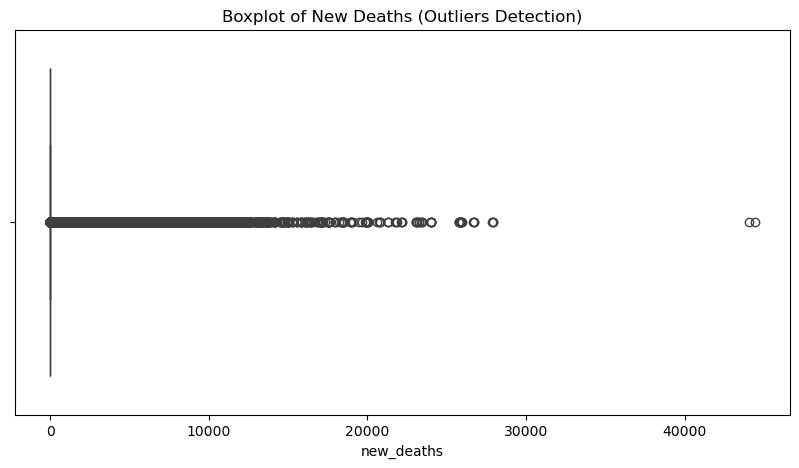

In [29]:
# I suspect there might be an outlier in new_deaths so I will plot it to visualize and confirm:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for new_deaths
plt.figure(figsize=(10, 5))
sns.boxplot(x=csv_data["new_deaths"])
plt.title("Boxplot of New Deaths (Outliers Detection)")
plt.show()


In [33]:
# Remove extreme outlier above 40000
csv_data = csv_data[csv_data["new_deaths"] <= 40000]

# Confirm that the outlier is removed
print(csv_data["new_deaths"].max())  # Should now be <= 40,000
# Will keep the others since these could be true extremes from certain countries.

27939.0


In [35]:
#STEP 8:aggregate the data to yearly level

#Get the year from date column
csv_data['year'] = csv_data['date'].dt.year 

#Aggregate specified columns by year and country
csv_aggregated = csv_data.groupby(['country', 'code', 'year']).agg({
    'new_cases': 'sum',  # Total number of new cases reported in the year
    'new_deaths': 'sum',  # Total number of new deaths reported in the year
    'new_tests': 'sum',  # Total number of new tests conducted in the year
    'total_vaccinations': 'max',  # Highest cumulative number of vaccinations administed by year's end
    'people_vaccinated': 'max',  # Highest cumulative number of people vaccinated by year's end
    'people_fully_vaccinated': 'max',  # Highest cumulative number of fully vaccinated people by year's end
    'total_boosters': 'max', # Highest cumulative number of booster doses administered by year's end
    'new_vaccinations': 'sum'  # Total number of new vaccinations administered in the year
}).reset_index()

# Display the first few rows of the aggregated dataset
print(csv_aggregated.head())

       country code  year  new_cases  new_deaths  new_tests  \
0  Afghanistan  AFG  2020    52330.0      2189.0        0.0   
1  Afghanistan  AFG  2021   105729.0      5167.0        0.0   
2  Afghanistan  AFG  2022    49495.0       493.0        0.0   
3  Afghanistan  AFG  2023    22821.0       124.0        0.0   
4  Afghanistan  AFG  2024     4839.0        25.0        0.0   

   total_vaccinations  people_vaccinated  people_fully_vaccinated  \
0                 0.0                0.0                      0.0   
1           4674518.0          4142857.0                3753224.0   
2          12449870.0         11459692.0               10754839.0   
3          22964750.0         19151368.0               18370386.0   
4          22964750.0         19151368.0               18370386.0   

   total_boosters  new_vaccinations  
0             0.0               0.0  
1             0.0          871193.0  
2             0.0         2450179.0  
3       2729940.0         2519516.0  
4       2729940.

In [37]:
print("Final dataset preview:")
print(csv_aggregated.head(50))  # Show first 50 rows

# Save for reference
csv_aggregated.to_csv("final_transformed_dataset.csv", index=False)
print("Full dataset saved as 'final_transformed_dataset.csv'.")

Final dataset preview:
                country code  year  new_cases  new_deaths   new_tests  \
0           Afghanistan  AFG  2020    52330.0      2189.0         0.0   
1           Afghanistan  AFG  2021   105729.0      5167.0         0.0   
2           Afghanistan  AFG  2022    49495.0       493.0         0.0   
3           Afghanistan  AFG  2023    22821.0       124.0         0.0   
4           Afghanistan  AFG  2024     4839.0        25.0         0.0   
5               Albania  ALB  2020    57146.0      1170.0    247526.0   
6               Albania  ALB  2021   151753.0      2042.0   1175840.0   
7               Albania  ALB  2022   123869.0       384.0    190504.0   
8               Albania  ALB  2023     1828.0         8.0         0.0   
9               Albania  ALB  2024     2600.0         4.0         0.0   
10              Algeria  DZA  2020    99311.0      2751.0         0.0   
11              Algeria  DZA  2021   118726.0      3520.0         0.0   
12              Algeria  DZA

# Ethical Implications  

In the data transformation and cleaning process applied to the COVID-19 flat file dataset (compact.csv), several transformations were performed, including updating datatypes, filtering out aggregate regions, handling missing values through forward-fill, and removing extreme outliers to ensure consistency. Data that involves public health information, must adhere to regulatory guidelines such as the General Data Protection Regulation (GDPR) for European data and the Health Insurance Portability and Accountability Act (HIPAA). However, since our data is pre-aggregated, we are not required to strictly comply with these regulations and instead we should ensure ethical practices such as transparency, bias awareness, and avoiding any reidentification risks. The modifications made, such as imputing missing values and filtering data by year, could introduce biases, potentially misrepresenting trends if they're not carefully validated. For example, assumptions were made that missing cumulative vaccination numbers could be inferred using forward-fill, which may not always accurately reflect real-world vaccination progress. The dataset is sourced from publicly available repositories, and while it is assumed credible, any data inaccuracies from the source could propagate through transformations. Ethical concerns also come up regarding data integrity and transparency, especially when handling missing data in ways that might influence public health insights. To mitigate these issues, transparency in the transformation process, regular validation against official health reports, and ethical considerations in result interpretation should always be top of mind.

In [39]:
print(csv_aggregated.dtypes)

country                     object
code                        object
year                         int32
new_cases                  float64
new_deaths                 float64
new_tests                  float64
total_vaccinations         float64
people_vaccinated          float64
people_fully_vaccinated    float64
total_boosters             float64
new_vaccinations           float64
dtype: object


In [41]:
# ADDING CODE TO LOAD MILESTONE 2 (Flatfile) DF INTO SQLite

import sqlite3
import pandas as pd

# Connect to (or create) the SQLite database
conn = sqlite3.connect("combined_data.db")  # Ensure all notebooks use the same filename

# Write the DataFrame to a table in SQLite
csv_aggregated.to_sql("covid_csv", conn, if_exists="replace", index=False)

# Close the connection
conn.close()